# Environment setup
Mount drive, install packages.

In [1]:
# Install dependencies
!pip install -q youtube-transcript-api transformers torch sentencepiece
import os
import json

# Mount drive and define project directory
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/lecture-summarizer'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 37.5 MB/s eta 0:00:00
Mounted at /content/drive


# Test data definition

Import raw test data transcripts from three lectures that cover three different subject areas. This uses the Youtube Transcript API (no Whisper needed)

In [2]:
from youtube_transcript_api import YouTubeTranscriptApi
import re

lectures = [
    {
        "id": "ml_neural_network",
        "title": "But what is a neural network? (3Blue1Brown)",
        "url": "https://www.youtube.com/watch?v=aircAruvnKk",
        "domain": "Machine Learning",
        "length_min": 18.65,
    },
    {
        "id": "history_neoliberalism",
        "title": "Neoliberalism and the End of History - Part 3",
        "url": "https://www.youtube.com/watch?v=oIp0_rAEMIs",
        "domain": "History",
        "length_min": 15.1,
    },
    {
        "id": "psych_wellbeing",
        "title": "Why Having More Doesn't Make You Happier (Science of Well-Being)",
        "url": "https://www.youtube.com/watch?v=_5qGVpy4-mc",
        "domain": "Psychology",
        "length_min": 26.57,
    },
]

def extract_video_id(url):
    """Extract YouTube video ID from various URL formats."""
    match = re.search(r'(?:v=|/)([0-9A-Za-z_-]{11}).*', url)
    return match.group(1) if match else None

api = YouTubeTranscriptApi()

for lec in lectures:
    video_id = extract_video_id(lec['url'])
    print(f"\n--- {lec['title']} ---")
    print(f"Video ID: {video_id}")
    try:
        # New API: instance method .fetch() returns a FetchedTranscript object
        fetched = api.fetch(video_id)
        # Each snippet is now an object with .text, .start, .duration attributes
        word_count = sum(len(snippet.text.split()) for snippet in fetched)
        print(f"✓ Transcript fetched: {len(fetched)} segments, ~{word_count} words")
        print(f"  First segment: \"{fetched[0].text[:80]}...\"")
    except Exception as e:
        print(f"✗ Failed: {type(e).__name__}: {e}")


--- But what is a neural network? (3Blue1Brown) ---
Video ID: aircAruvnKk
✓ Transcript fetched: 286 segments, ~3357 words
  First segment: "This is a 3...."

--- Neoliberalism and the End of History - Part 3 ---
Video ID: oIp0_rAEMIs
✓ Transcript fetched: 301 segments, ~2057 words
  First segment: "The following content is
provided under a Creative..."

--- Why Having More Doesn't Make You Happier (Science of Well-Being) ---
Video ID: _5qGVpy4-mc
✓ Transcript fetched: 825 segments, ~5857 words
  First segment: "Okay. So, what's annoying feature number..."


Saving the raw (unprocessed) lecture transcripts to drive

In [3]:
for lec in lectures:
    video_id = extract_video_id(lec['url'])
    fetched = api.fetch(video_id)

    # Convert FetchedTranscript snippets to plain dicts for JSON serialization
    transcript_data = [
        {"text": snippet.text, "start": snippet.start, "duration": snippet.duration}
        for snippet in fetched
    ]

    # Save full structured transcript (with timestamps) to data/raw/
    raw_path = f"{PROJECT_DIR}/data/raw/{lec['id']}.json"
    with open(raw_path, 'w') as f:
        json.dump({
            "metadata": lec,
            "video_id": video_id,
            "segments": transcript_data,
            "word_count": sum(len(s['text'].split()) for s in transcript_data),
        }, f, indent=2)

    print(f"Saved {raw_path}")

print("\nAll transcripts saved to data/raw/")

Saved /content/drive/MyDrive/lecture-summarizer/data/raw/ml_neural_network.json
Saved /content/drive/MyDrive/lecture-summarizer/data/raw/history_neoliberalism.json
Saved /content/drive/MyDrive/lecture-summarizer/data/raw/psych_wellbeing.json

All transcripts saved to data/raw/


Cleaning the raw test transcripts so that:

*   Join segment texts with spaces
*   Replace new lines with spaces
*   Collapse multiple whitespace into single spaces

In [4]:
def clean_transcript(segments):
    """Join transcript segments into clean running text."""
    # Join all segment texts with spaces
    raw_text = ' '.join(seg['text'] for seg in segments)

    # Replace newlines (which appear within segments) with spaces
    cleaned = raw_text.replace('\n', ' ')

    # Collapse multiple whitespace into single spaces
    import re
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    return cleaned

# Process each transcript
for lec in lectures:
    raw_path = f"{PROJECT_DIR}/data/raw/{lec['id']}.json"
    with open(raw_path, 'r') as f:
        data = json.load(f)

    cleaned_text = clean_transcript(data['segments'])

    processed_path = f"{PROJECT_DIR}/data/processed/{lec['id']}.txt"
    with open(processed_path, 'w') as f:
        f.write(cleaned_text)

# Generating a preview of the transcripts to sanity check that all is well.
    print(f"{lec['id']}: {len(cleaned_text.split())} words")
    print(f"  First 200 chars: \"{cleaned_text[:200]}...\"")
    print(f"  Saved to {processed_path}\n")

ml_neural_network: 3357 words
  First 200 chars: "This is a 3. It's sloppily written and rendered at an extremely low resolution of 28x28 pixels, but your brain has no trouble recognizing it as a 3. And I want you to take a moment to appreciate how c..."
  Saved to /content/drive/MyDrive/lecture-summarizer/data/processed/ml_neural_network.txt

history_neoliberalism: 2057 words
  First 200 chars: "The following content is provided under a Creative Commons license. Your support will help MIT OpenCourseWare continue to offer high-quality educational resources for free. To make a donation, or to v..."
  Saved to /content/drive/MyDrive/lecture-summarizer/data/processed/history_neoliberalism.txt

psych_wellbeing: 5857 words
  First 200 chars: "Okay. So, what's annoying feature number two? Annoying feature of the mind number two, which is rampant throughout the mind, is that our minds just don't think in terms of absolutes. We just don't thi..."
  Saved to /content/drive/MyDrive/lecture-summa

Exploratory analysis of test data

In [5]:
print(f"{'Lecture':<30} {'Words':>8} {'Tokens (est)':>14} {'Chunks @ 1024':>16}")
print("-" * 70)

for lec in lectures:
    processed_path = f"{PROJECT_DIR}/data/processed/{lec['id']}.txt"
    with open(processed_path, 'r') as f:
        text = f.read()

    words = len(text.split())
    # Rough estimate: 1 token ≈ 0.75 words for English
    est_tokens = int(words / 0.75)
    # Number of 1024-token chunks needed
    n_chunks = (est_tokens // 1024) + 1

    print(f"{lec['id']:<30} {words:>8} {est_tokens:>14} {n_chunks:>14}")

Lecture                           Words   Tokens (est)    Chunks @ 1024
----------------------------------------------------------------------
ml_neural_network                  3357           4476              5
history_neoliberalism              2057           2742              3
psych_wellbeing                    5857           7809              8


# EDA of **training** data

For finetuning, we train on a database. Let's import the data which is an arxiv-summarization dataset

In [6]:
# Install the datasets library if not already installed
!pip install -q datasets

from datasets import load_dataset

# Load arxiv-summarization
# This will download ~600MB the first time
print("Loading ccdv/arxiv-summarization...")
arxiv = load_dataset("ccdv/arxiv-summarization", trust_remote_code=True)

print(f"\nDataset structure: {arxiv}")
print(f"\nTrain size: {len(arxiv['train'])}")
print(f"Validation size: {len(arxiv['validation'])}")
print(f"Test size: {len(arxiv['test'])}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/arxiv-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ccdv/arxiv-summarization' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading ccdv/arxiv-summarization...


README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00015.parquet:   0%|          | 0.00/230M [00:00<?, ?B/s]

section/train-00001-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]


Dataset structure: DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 203037
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6436
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6440
    })
})

Train size: 203037
Validation size: 6436
Test size: 6440


Quick sanity check of the first entry (i.e. the sample) to ensure we have the right Article-Abstract format

In [7]:
sample = arxiv['train'][0]
print("Available keys:", list(sample.keys()))
print(f"\n--- Article (first 500 chars) ---")
print(sample['article'][:500])
print(f"\n--- Abstract ---")
print(sample['abstract'])
print(f"\n--- Lengths ---")
print(f"Article: {len(sample['article'].split())} words")
print(f"Abstract: {len(sample['abstract'].split())} words")

Available keys: ['article', 'abstract']

--- Article (first 500 chars) ---
additive models @xcite provide an important family of models for semiparametric regression or classification . some reasons for the success of additive models are their increased flexibility when compared to linear or generalized linear models and their increased interpretability when compared to fully nonparametric models . 
 it is well - known that good estimators in additive models are in general less prone to the curse of high dimensionality than good estimators in fully nonparametric models

--- Abstract ---
additive models play an important role in semiparametric statistics . 
 this paper gives learning rates for regularized kernel based methods for additive models . 
 these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quantile regression using the gaussian radial basis function kernel , prov

If training data sample passes the initial smell test, then move to do EDA on a larger subset:

In [8]:
# Take a random 5K subset of training data
# Use a seed for reproducibility
TRAIN_SIZE = 5000
VAL_SIZE = 500  # small validation set to check progress

train_subset = arxiv['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
val_subset = arxiv['validation'].shuffle(seed=42).select(range(VAL_SIZE))

print(f"Training subset: {len(train_subset)} examples")
print(f"Validation subset: {len(val_subset)} examples")

# Quick stats
train_article_lens = [len(ex['article'].split()) for ex in train_subset.select(range(100))]
train_abstract_lens = [len(ex['abstract'].split()) for ex in train_subset.select(range(100))]

print(f"\nFirst 100 training samples (word counts):")
print(f"  Article:  median={sorted(train_article_lens)[50]}, max={max(train_article_lens)}, min={min(train_article_lens)}")
print(f"  Abstract: median={sorted(train_abstract_lens)[50]}, max={max(train_abstract_lens)}, min={min(train_abstract_lens)}")

Training subset: 5000 examples
Validation subset: 500 examples

First 100 training samples (word counts):
  Article:  median=4465, max=20703, min=330
  Abstract: median=190, max=4339, min=24


You might note that there is a lot of variablity in the artivle and abstact word count from looknig at the data. This might indicate that we will have to further process the data so that those edge cases do not unduly influence the model.

Filter dataset and plot results for comparison:

Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/500 [00:00<?, ? examples/s]

DATA CLEANING SUMMARY
Filter criteria: article 200-15,000 words, abstract 50-400 words, compression ratio ≤ 30%

Zero-word articles  BEFORE: 3  AFTER: 0
Zero-word abstracts BEFORE: 0  AFTER: 0
Invalid ratios (NaN/Inf) BEFORE: 3
Ratios > 100% BEFORE: 112
Ratios > 80%  BEFORE: 120
Ratios > 30% BEFORE: 168  AFTER: 0

Filtering: 5000 → 4354 (12.9% removed)

COMPRESSION RATIO (abstract words / article words)
                      Mean     Median        Min        Max        Std
----------------------------------------------------------------------
Before             38.86%     3.12%     0.05% 12311.36%   480.65%
After               3.93%     3.13%     0.46%    29.33%     2.88%

Figure saved to /content/drive/MyDrive/lecture-summarizer/data/processed/length_distributions.png


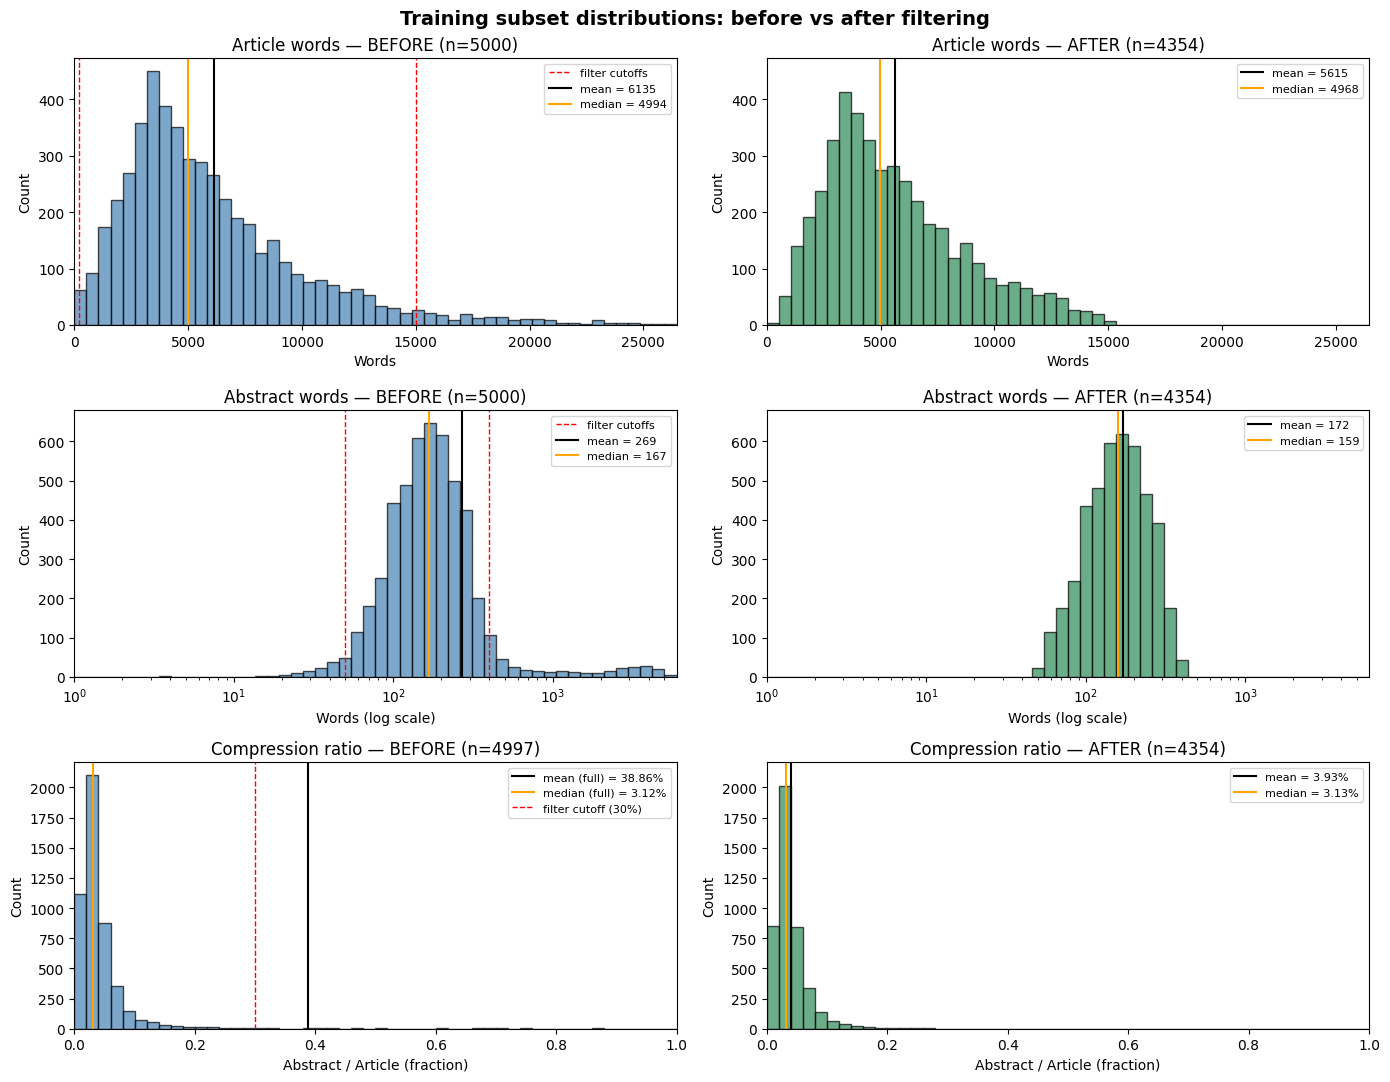

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Compute lengths and ratios BEFORE filtering, safely
before_article_lens = np.array([len(ex['article'].split()) for ex in train_subset])
before_abstract_lens = np.array([len(ex['abstract'].split()) for ex in train_subset])

# Diagnostic: count edge cases
n_zero_articles_before = (before_article_lens == 0).sum()
n_zero_abstracts_before = (before_abstract_lens == 0).sum()

# Compute ratios safely
with np.errstate(divide='ignore', invalid='ignore'):
    before_ratios_raw = before_abstract_lens / before_article_lens

valid_before_mask = np.isfinite(before_ratios_raw)
before_ratios = before_ratios_raw[valid_before_mask]
n_invalid_before = (~valid_before_mask).sum()

# Count how many BEFORE examples exceed compression thresholds
n_ratio_over_100 = (before_ratios > 1.0).sum()
n_ratio_over_80 = (before_ratios > 0.8).sum()
n_ratio_over_30 = (before_ratios > 0.3).sum()

# ---- FILTER (UPDATED to 30%) ----
COMPRESSION_RATIO_MAX = 0.3  # 30% — keeps only genuinely aggressive summaries

def filter_reasonable_length(example):
    article_words = len(example['article'].split())
    abstract_words = len(example['abstract'].split())
    if article_words < 200 or article_words > 15000:
        return False
    if abstract_words < 50 or abstract_words > 400:
        return False
    ratio = abstract_words / article_words
    if ratio > COMPRESSION_RATIO_MAX:
        return False
    return True

train_subset_filtered = train_subset.filter(filter_reasonable_length)
val_subset_filtered = val_subset.filter(filter_reasonable_length)

# Compute lengths and ratios AFTER filtering
after_article_lens = np.array([len(ex['article'].split()) for ex in train_subset_filtered])
after_abstract_lens = np.array([len(ex['abstract'].split()) for ex in train_subset_filtered])
after_ratios = after_abstract_lens / after_article_lens

# Sanity checks
n_zero_articles_after = (after_article_lens == 0).sum()
n_zero_abstracts_after = (after_abstract_lens == 0).sum()
n_ratio_over_threshold_after = (after_ratios > COMPRESSION_RATIO_MAX).sum()

# ---- Print diagnostic summary ----
print("=" * 70)
print("DATA CLEANING SUMMARY")
print("=" * 70)
print(f"Filter criteria: article 200-15,000 words, abstract 50-400 words, "
      f"compression ratio ≤ {COMPRESSION_RATIO_MAX:.0%}")
print()
print(f"Zero-word articles  BEFORE: {n_zero_articles_before}  AFTER: {n_zero_articles_after}")
print(f"Zero-word abstracts BEFORE: {n_zero_abstracts_before}  AFTER: {n_zero_abstracts_after}")
print(f"Invalid ratios (NaN/Inf) BEFORE: {n_invalid_before}")
print(f"Ratios > 100% BEFORE: {n_ratio_over_100}")
print(f"Ratios > 80%  BEFORE: {n_ratio_over_80}")
print(f"Ratios > {COMPRESSION_RATIO_MAX:.0%} BEFORE: {n_ratio_over_30}  AFTER: {n_ratio_over_threshold_after}")
print()
print(f"Filtering: {len(train_subset)} → {len(train_subset_filtered)} "
      f"({100*(1-len(train_subset_filtered)/len(train_subset)):.1f}% removed)")
print()

# ---- Compression ratio table ----
print("=" * 70)
print("COMPRESSION RATIO (abstract words / article words)")
print("=" * 70)
print(f"{'':<15} {'Mean':>10} {'Median':>10} {'Min':>10} {'Max':>10} {'Std':>10}")
print("-" * 70)
print(f"{'Before':<15} {np.mean(before_ratios):>9.2%} {np.median(before_ratios):>9.2%} "
      f"{before_ratios.min():>9.2%} {before_ratios.max():>9.2%} {np.std(before_ratios):>9.2%}")
print(f"{'After':<15} {np.mean(after_ratios):>9.2%} {np.median(after_ratios):>9.2%} "
      f"{after_ratios.min():>9.2%} {after_ratios.max():>9.2%} {np.std(after_ratios):>9.2%}")

# ---- Build axis ranges ----
article_xmax = np.percentile(before_article_lens, 99.5)
abstract_xmax = max(before_abstract_lens.max(), after_abstract_lens.max())
ratio_xmax = 1.0  # keep visible range at 100% so we can see the cutoff in context

article_bins = np.linspace(0, article_xmax, 51)
abstract_bins = np.logspace(0, np.log10(abstract_xmax), 51)
ratio_bins = np.linspace(0, ratio_xmax, 51)

# Compute y-axis limits per row
art_b, _ = np.histogram(before_article_lens, bins=article_bins)
art_a, _ = np.histogram(after_article_lens, bins=article_bins)
article_ymax = max(art_b.max(), art_a.max()) * 1.05

abs_b, _ = np.histogram(before_abstract_lens, bins=abstract_bins)
abs_a, _ = np.histogram(after_abstract_lens, bins=abstract_bins)
abstract_ymax = max(abs_b.max(), abs_a.max()) * 1.05

rat_b, _ = np.histogram(before_ratios, bins=ratio_bins)
rat_a, _ = np.histogram(after_ratios, bins=ratio_bins)
ratio_ymax = max(rat_b.max(), rat_a.max()) * 1.05

# ---- Build 3-row figure ----
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('Training subset distributions: before vs after filtering', fontsize=14, fontweight='bold')

# ===== Row 1: Article words =====
axes[0, 0].hist(before_article_lens, bins=article_bins, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(200, color='red', linestyle='--', linewidth=1, label='filter cutoffs')
axes[0, 0].axvline(15000, color='red', linestyle='--', linewidth=1)
axes[0, 0].axvline(np.mean(before_article_lens), color='black', linestyle='-', linewidth=1.5,
                   label=f'mean = {np.mean(before_article_lens):.0f}')
axes[0, 0].axvline(np.median(before_article_lens), color='orange', linestyle='-', linewidth=1.5,
                   label=f'median = {np.median(before_article_lens):.0f}')
axes[0, 0].set_title(f'Article words — BEFORE (n={len(before_article_lens)})')
axes[0, 0].set_xlabel('Words')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlim(0, article_xmax)
axes[0, 0].set_ylim(0, article_ymax)
axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(after_article_lens, bins=article_bins, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.mean(after_article_lens), color='black', linestyle='-', linewidth=1.5,
                   label=f'mean = {np.mean(after_article_lens):.0f}')
axes[0, 1].axvline(np.median(after_article_lens), color='orange', linestyle='-', linewidth=1.5,
                   label=f'median = {np.median(after_article_lens):.0f}')
axes[0, 1].set_title(f'Article words — AFTER (n={len(after_article_lens)})')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlim(0, article_xmax)
axes[0, 1].set_ylim(0, article_ymax)
axes[0, 1].legend(fontsize=8)

# ===== Row 2: Abstract words (LOG x-axis) =====
axes[1, 0].hist(before_abstract_lens, bins=abstract_bins, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(50, color='red', linestyle='--', linewidth=1, label='filter cutoffs')
axes[1, 0].axvline(400, color='red', linestyle='--', linewidth=1)
axes[1, 0].axvline(np.mean(before_abstract_lens), color='black', linestyle='-', linewidth=1.5,
                   label=f'mean = {np.mean(before_abstract_lens):.0f}')
axes[1, 0].axvline(np.median(before_abstract_lens), color='orange', linestyle='-', linewidth=1.5,
                   label=f'median = {np.median(before_abstract_lens):.0f}')
axes[1, 0].set_title(f'Abstract words — BEFORE (n={len(before_abstract_lens)})')
axes[1, 0].set_xlabel('Words (log scale)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlim(1, abstract_xmax)
axes[1, 0].set_ylim(0, abstract_ymax)
axes[1, 0].legend(fontsize=8)

axes[1, 1].hist(after_abstract_lens, bins=abstract_bins, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(np.mean(after_abstract_lens), color='black', linestyle='-', linewidth=1.5,
                   label=f'mean = {np.mean(after_abstract_lens):.0f}')
axes[1, 1].axvline(np.median(after_abstract_lens), color='orange', linestyle='-', linewidth=1.5,
                   label=f'median = {np.median(after_abstract_lens):.0f}')
axes[1, 1].set_title(f'Abstract words — AFTER (n={len(after_abstract_lens)})')
axes[1, 1].set_xlabel('Words (log scale)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlim(1, abstract_xmax)
axes[1, 1].set_ylim(0, abstract_ymax)
axes[1, 1].legend(fontsize=8)

# ===== Row 3: Compression ratio =====
axes[2, 0].hist(before_ratios, bins=ratio_bins, color='steelblue', edgecolor='black', alpha=0.7)
axes[2, 0].axvline(np.mean(before_ratios), color='black', linestyle='-', linewidth=1.5,
                   label=f'mean (full) = {np.mean(before_ratios):.2%}')
axes[2, 0].axvline(np.median(before_ratios), color='orange', linestyle='-', linewidth=1.5,
                   label=f'median (full) = {np.median(before_ratios):.2%}')
axes[2, 0].axvline(COMPRESSION_RATIO_MAX, color='red', linestyle='--', linewidth=1,
                   label=f'filter cutoff ({COMPRESSION_RATIO_MAX:.0%})')
axes[2, 0].set_title(f'Compression ratio — BEFORE (n={len(before_ratios)})')
axes[2, 0].set_xlabel('Abstract / Article (fraction)')
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_xlim(0, ratio_xmax)
axes[2, 0].set_ylim(0, ratio_ymax)
axes[2, 0].legend(fontsize=8)

axes[2, 1].hist(after_ratios, bins=ratio_bins, color='seagreen', edgecolor='black', alpha=0.7)
axes[2, 1].axvline(np.mean(after_ratios), color='black', linestyle='-', linewidth=1.5,
                   label=f'mean = {np.mean(after_ratios):.2%}')
axes[2, 1].axvline(np.median(after_ratios), color='orange', linestyle='-', linewidth=1.5,
                   label=f'median = {np.median(after_ratios):.2%}')
axes[2, 1].set_title(f'Compression ratio — AFTER (n={len(after_ratios)})')
axes[2, 1].set_xlabel('Abstract / Article (fraction)')
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_xlim(0, ratio_xmax)
axes[2, 1].set_ylim(0, ratio_ymax)
axes[2, 1].legend(fontsize=8)

plt.tight_layout()

fig_path = f'{PROJECT_DIR}/data/processed/length_distributions.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"\nFigure saved to {fig_path}")
plt.show()